In [ ]:
%pip install antropy

In [ ]:
import mne
import numpy as np
import os
import pandas as pd
import warnings

import antropy as ant

warnings.filterwarnings('ignore')

In [ ]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

In [ ]:
# Shows the first 5 rows of the table with all columns
display(df_complete.head())

print(f"\nTotal patients with pain scores: {df_complete.shape[0]}")
print(f"Total merged columns: {df_complete.shape[1]}")

,ID,Pain Score (Actual Pain of Brief Pain Inventory),Age,Gender,Etiology of NP*,Time with NP,Medical treatment for NP,Since when have you use the previous medication?,Have you had any medical procedures to control the pain?,Do you go regularly to phsychological or emotional counseling sessions for your pain?,...,Please write your main area of pain,Does your pain radiate to other regions of your body?,"If the answer is yes, please write the direction in which it irradiates as explicitly as possible","Do you suffer from a burning sensation (e.g., stinging nettles) in the marked areas?",Do you have a tingling or prickling sensation in the area of your pain (like crawling ants or electrical tingling)?,"Is light touching (clothing, a blanket) in this area painful?","Do you have sudden pain attacks in the area of your pain, like electric shocks?",Is cold or heat (bath water) in this area occasionally painful?,Do you suffer from a sensation of numbness in the areas that you marked?,"Does slight pressure in this area, e.g., with a finger, trigger pain?"
0,0,7.0,25.0,F,Central Nervous System Disorder (CRPS or Lyme),More than 2 years,"Pregabalin, amitriptyline",More than a year ago,Nerve blocks and infusions*,Yes,...,Soles of feet and palms of hands,Yes,"From the feet to lower back, from the hands to...",Strongly,Strongly,Strongly,Very Strongly,Very Strongly,Strongly,Moderately
1,1,4.0,57.0,F,Diabetes,More than 2 years,Tramadol,More than a month ago,NaN,No,...,Sole of feet,No,NaN,Very Strongly,Strongly,Strongly,Strongly,Strongly,Strongly,Strongly
2,2,3.0,20.0,F,Peripheral neuropathy,More than 2 years,Keterolac,More than a year ago,NaN,No,...,Wrist and hand,Yes,From the wrist to the fingers,Never,Moderately,Never,Moderately,Strongly,Very Strongly,Slightly
3,3,8.0,34.0,F,Spinal cord or nerve root injury,More than 2 years,Tramadol,More than a year ago,Physiotherapy,No,...,Lower back,No,NaN,Strongly,Moderately,Never,Never,Moderately,Never,Very Strongly
4,4,5.0,77.0,M,Spinal cord or nerve root injury,More than 2 years,NaN,NaN,NaN,No,...,"Legs, back, neck and head",Yes,To the limbs,Never,Strongly,Never,Strongly,Never,Strongly,Strongly



Total patients with pain scores: 36
Total merged columns: 35


In [ ]:
csv_filename = 'eeg_model_results_eo_ec.csv'
current_condition = 'Eyes Closed'

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Existing table loaded with {len(df_results)} records")
else:
    # Defining the columns
    columns = ['Model', 'Condition', 'Accuracy', 'AUC_ROC', 'F1_Score']
    df_results = pd.DataFrame(columns=columns)
    print("New table created successfully")

if 'model_results' not in locals():
    model_results = {}

New table created successfully


In [ ]:
asymmetry_pairs = {
    'Fp1': 'Fp2',
    'F3': 'F4',
    'C3': 'C4',
    'P3': 'P4',
    'O1': 'O2',
    'F7': 'F8',
    'T7': 'T8',
    'P7': 'P8'
}

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

clinical_bands = {
    'Delta': (0.1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

X_features = []
y_labels = []
feature_names = []
model_results = {}
eeg_folder = './cleaned' 

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

In [ ]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Hjorth + ApEn sem assimetria

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eo_epochs.fif")
    
    if os.path.exists(path):
        try:
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            all_channels = epochs.ch_names
            sfreq = epochs.info['sfreq']
            
            epochs_data = epochs.get_data() # (n_epochs, n_channels, n_times)
            
            patient_features = []
            channel_metrics = {}
            temp_names = [] 
            
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_epochs = epochs_data[:, i, :] # Isola o canal (n_epochs, n_times)
                    
                    channel_metrics[channel] = {}
                    
                    # HJORTH (Broadband)
                    activity_epochs = np.var(channel_epochs, axis=1)
                    activity = np.mean(activity_epochs)
                    
                    mobility_epochs, complexity_epochs = ant.hjorth_params(channel_epochs, axis=1)
                    mobility = np.mean(mobility_epochs)
                    complexity = np.mean(complexity_epochs)
                    
                    channel_metrics[channel]['Hjorth_Activity'] = activity
                    channel_metrics[channel]['Hjorth_Mobility'] = mobility
                    channel_metrics[channel]['Hjorth_Complexity'] = complexity
                    
                    patient_features.extend([activity, mobility, complexity])
                    if not feature_names: 
                        temp_names.extend([f"Hjorth_Activity_{channel}", f"Hjorth_Mobility_{channel}", f"Hjorth_Complexity_{channel}"])
                
                    # ApEn
                    def compute_apen(data_epochs):
                        """Calcula a média do ApEn de todas as epochs com m=3 e r=0.2*std"""
                        apen_vals = []
                        for ep_idx in range(data_epochs.shape[0]):
                            x = data_epochs[ep_idx, :]
                            tol = 0.2 * np.std(x)
                            ap = ant.app_entropy(x, order=3, tolerance=tol)
                            apen_vals.append(ap)
                        return np.mean(apen_vals)

                    # ApEn Broadband (0.1 - 100 Hz)
                    apen_bb = compute_apen(channel_epochs)
                    channel_metrics[channel]['ApEn_Broadband'] = apen_bb
                    patient_features.append(apen_bb)
                    if not feature_names: temp_names.append(f"ApEn_Broadband_{channel}")
                    
                    # ApEn nas 5 bandas
                    for band_name, (fmin, fmax) in clinical_bands.items():
                        filtered_epochs = mne.filter.filter_data(channel_epochs, sfreq, l_freq=fmin, h_freq=fmax, verbose=False)
                        
                        apen_band = compute_apen(filtered_epochs)
                        channel_metrics[channel][f'ApEn_{band_name}'] = apen_band
                        
                        patient_features.append(apen_band)
                        if not feature_names: temp_names.append(f"ApEn_{band_name}_{channel}")
                        
                else:
                    # Preenchimento em caso de canal ausente (Hjorth: 3 + ApEn: 1 BB + 5 Bandas)
                    patient_features.extend([np.nan] * 9)
                    if not feature_names:
                        temp_names.extend([f"Hjorth_Activity_{channel}", f"Hjorth_Mobility_{channel}", f"Hjorth_Complexity_{channel}"])
                        temp_names.append(f"ApEn_Broadband_{channel}")
                        for band_name in clinical_bands.keys():
                            temp_names.append(f"ApEn_{band_name}_{channel}")

            if not feature_names: feature_names = temp_names
            
            X_features.append(patient_features)
            y_labels.append(pain_score)
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

X = np.array(X_features)
y = np.array(y_labels)

valid_columns = ~np.isnan(X).all(axis=0)
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns].tolist()

print("\n--- EXTRAÇÃO NÃO-LINEAR CONCLUÍDA ---")
print(f"Formato Final da Matriz (X): {X.shape}")
print(f"Total de Biomarcadores Válidos: {len(feature_names)}")

Iniciando extração de Parâmetros de Hjorth e Entropia Aproximada (ApEn) SEM Assimetria...
[OK] Processamento do paciente 0 finalizado.
[OK] Processamento do paciente 1 finalizado.
[OK] Processamento do paciente 2 finalizado.
[OK] Processamento do paciente 3 finalizado.
[OK] Processamento do paciente 4 finalizado.
[OK] Processamento do paciente 5 finalizado.
[OK] Processamento do paciente 6 finalizado.
[OK] Processamento do paciente 7 finalizado.
[OK] Processamento do paciente 8 finalizado.
[OK] Processamento do paciente 9 finalizado.
[OK] Processamento do paciente 10 finalizado.
[OK] Processamento do paciente 11 finalizado.
[OK] Processamento do paciente 13 finalizado.
[OK] Processamento do paciente 15 finalizado.
[OK] Processamento do paciente 16 finalizado.
[OK] Processamento do paciente 18 finalizado.
[OK] Processamento do paciente 19 finalizado.
[OK] Processamento do paciente 20 finalizado.
[OK] Processamento do paciente 21 finalizado.
[OK] Processamento do paciente 22 finalizado.


In [ ]:
# Hjorth + ApEn com assimetria
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eo_epochs.fif")
    
    if os.path.exists(path):
        try:
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            all_channels = epochs.ch_names
            sfreq = epochs.info['sfreq']
            
            epochs_data = epochs.get_data() # (n_epochs, n_channels, n_times)
            
            patient_features = []
            channel_metrics = {}
            temp_names = [] 
            
            # --- LOOP DE CANAIS ---
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_epochs = epochs_data[:, i, :] # Isola o canal (n_epochs, n_times)
                    
                    channel_metrics[channel] = {}
                    
                    # PARÂMETROS DE HJORTH (Broadband)
                    activity_epochs = np.var(channel_epochs, axis=1)
                    activity = np.mean(activity_epochs)
                    
                    mobility_epochs, complexity_epochs = ant.hjorth_params(channel_epochs, axis=1)
                    mobility = np.mean(mobility_epochs)
                    complexity = np.mean(complexity_epochs)
                    
                    channel_metrics[channel]['Hjorth_Activity'] = activity
                    channel_metrics[channel]['Hjorth_Mobility'] = mobility
                    channel_metrics[channel]['Hjorth_Complexity'] = complexity
                    
                    patient_features.extend([activity, mobility, complexity])
                    if not feature_names: 
                        temp_names.extend([f"Hjorth_Activity_{channel}", f"Hjorth_Mobility_{channel}", f"Hjorth_Complexity_{channel}"])
                    
                    # ENTROPIA APROXIMADA (ApEn)
                    def compute_apen(data_epochs):
                        """Calcula a média do ApEn de todas as epochs com m=3 e r=0.2*std"""
                        apen_vals = []
                        for ep_idx in range(data_epochs.shape[0]):
                            x = data_epochs[ep_idx, :]
                            # Nota matemática: O padrão ouro para o 'r' (tolerance) é 0.2 vezes o 
                            # desvio padrão da janela. Na literatura é comum ver o termo "variância" 
                            # sendo usado de forma intercambiável, mas a fórmula clássica usa std().
                            tol = 0.2 * np.std(x)
                            
                            # m=3 corresponde ao parâmetro 'order=3'
                            ap = ant.app_entropy(x, order=3, tolerance=tol)
                            apen_vals.append(ap)
                        return np.mean(apen_vals)

                    # ApEn Broadband (0.1 - 100 Hz)
                    apen_bb = compute_apen(channel_epochs)
                    channel_metrics[channel]['ApEn_Broadband'] = apen_bb
                    patient_features.append(apen_bb)
                    if not feature_names: temp_names.append(f"ApEn_Broadband_{channel}")
                    
                    # 2.2 ApEn nas 5 Bandas Clínicas
                    for band_name, (fmin, fmax) in clinical_bands.items():
                        # Filtra todas as epochs do canal para a banda específica
                        filtered_epochs = mne.filter.filter_data(channel_epochs, sfreq, l_freq=fmin, h_freq=fmax, verbose=False)
                        
                        apen_band = compute_apen(filtered_epochs)
                        channel_metrics[channel][f'ApEn_{band_name}'] = apen_band
                        
                        patient_features.append(apen_band)
                        if not feature_names: temp_names.append(f"ApEn_{band_name}_{channel}")
                        
                else:
                    # Preenchimento em caso de canal ausente (Hjorth: 3 + ApEn: 1 BB + 5 Bandas)
                    patient_features.extend([np.nan] * 9)
                    if not feature_names:
                        temp_names.extend([f"Hjorth_Activity_{channel}", f"Hjorth_Mobility_{channel}", f"Hjorth_Complexity_{channel}"])
                        temp_names.append(f"ApEn_Broadband_{channel}")
                        for band_name in clinical_bands.keys():
                            temp_names.append(f"ApEn_{band_name}_{channel}")

            # LOOP DE ASSIMETRIA HEMISFÉRICA
            epsilon = 1e-10 
            
            for left_channel, right_channel in asymmetry_pairs.items():
                if left_channel in channel_metrics and right_channel in channel_metrics:
                    
                    # Varre todas as métricas extraídas (Hjorth e ApEn) para calcular a assimetria
                    for metric_name in channel_metrics[left_channel].keys():
                        val_left = channel_metrics[left_channel][metric_name]
                        val_right = channel_metrics[right_channel][metric_name]
                        
                        asymmetry = np.log(max(val_right, epsilon) / max(val_left, epsilon))
                        patient_features.append(asymmetry)
                        
                        if not feature_names: 
                            temp_names.append(f"Asym_{metric_name}_{left_channel}-{right_channel}")
                else:
                    # Preenchimento de assimetria para canais ausentes (9 métricas)
                    patient_features.extend([np.nan] * 9)
                    if not feature_names: 
                        metrics_list = ['Hjorth_Activity', 'Hjorth_Mobility', 'Hjorth_Complexity', 'ApEn_Broadband'] + [f"ApEn_{b}" for b in clinical_bands.keys()]
                        for metric_name in metrics_list:
                            temp_names.append(f"Asym_{metric_name}_{left_channel}-{right_channel}")
            
            if not feature_names: feature_names = temp_names
            
            X_features.append(patient_features)
            y_labels.append(pain_score)
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

X = np.array(X_features)
y = np.array(y_labels)

valid_columns = ~np.isnan(X).all(axis=0)
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns].tolist()

print("\n--- EXTRAÇÃO NÃO-LINEAR CONCLUÍDA ---")
print(f"Formato Final da Matriz (X): {X.shape}")
print(f"Total de Biomarcadores Válidos: {len(feature_names)}")

[OK] Processamento do paciente 0 finalizado.
[OK] Processamento do paciente 1 finalizado.
[OK] Processamento do paciente 2 finalizado.
[OK] Processamento do paciente 3 finalizado.
[OK] Processamento do paciente 4 finalizado.
[OK] Processamento do paciente 5 finalizado.
[OK] Processamento do paciente 6 finalizado.
[OK] Processamento do paciente 7 finalizado.
[OK] Processamento do paciente 8 finalizado.
[OK] Processamento do paciente 9 finalizado.
[OK] Processamento do paciente 10 finalizado.
[OK] Processamento do paciente 11 finalizado.
[OK] Processamento do paciente 13 finalizado.
[OK] Processamento do paciente 15 finalizado.
[OK] Processamento do paciente 16 finalizado.
[OK] Processamento do paciente 18 finalizado.
[OK] Processamento do paciente 19 finalizado.
[OK] Processamento do paciente 20 finalizado.
[OK] Processamento do paciente 21 finalizado.
[OK] Processamento do paciente 22 finalizado.
[OK] Processamento do paciente 23 finalizado.
[OK] Processamento do paciente 24 finalizado

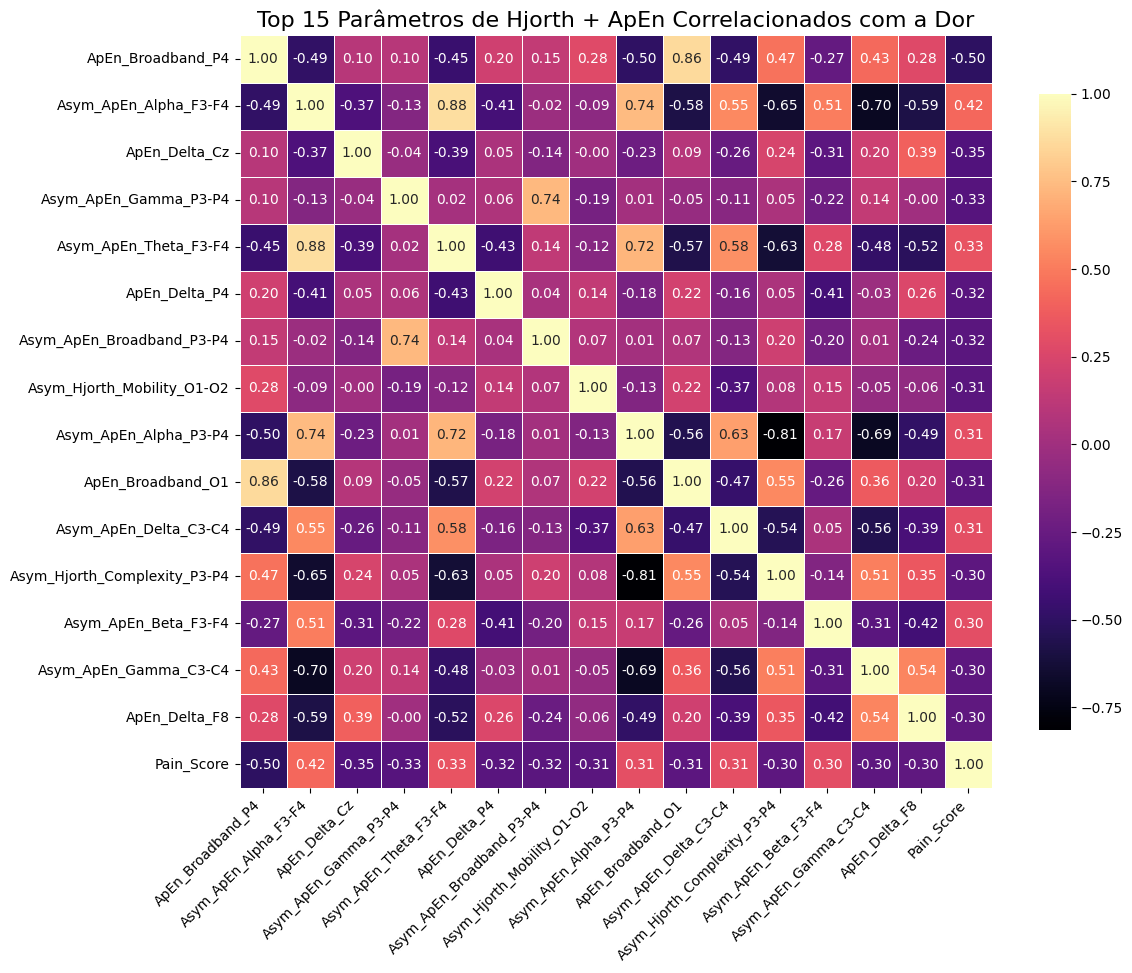

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_hjorth = pd.DataFrame(X, columns=feature_names)
df_hjorth['Pain_Score'] = y

correlations_hjorth = df_hjorth.corr()['Pain_Score'].drop('Pain_Score').abs().sort_values(ascending=False)
top_hjorth_features = correlations_hjorth.head(15).index.tolist()

plt.figure(figsize=(12, 10))
corr_matrix_hjorth = df_hjorth[top_hjorth_features + ['Pain_Score']].corr()
sns.heatmap(corr_matrix_hjorth, annot=True, cmap='magma', fmt=".2f", square=True, 
            cbar_kws={"shrink": .8}, linewidths=.5)

plt.title("Top 15 Parâmetros de Hjorth + ApEn Correlacionados com a Dor", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('comAssimetria_matriz_correlacao_hjorth_apen.png', dpi=300, bbox_inches='tight')
plt.show()

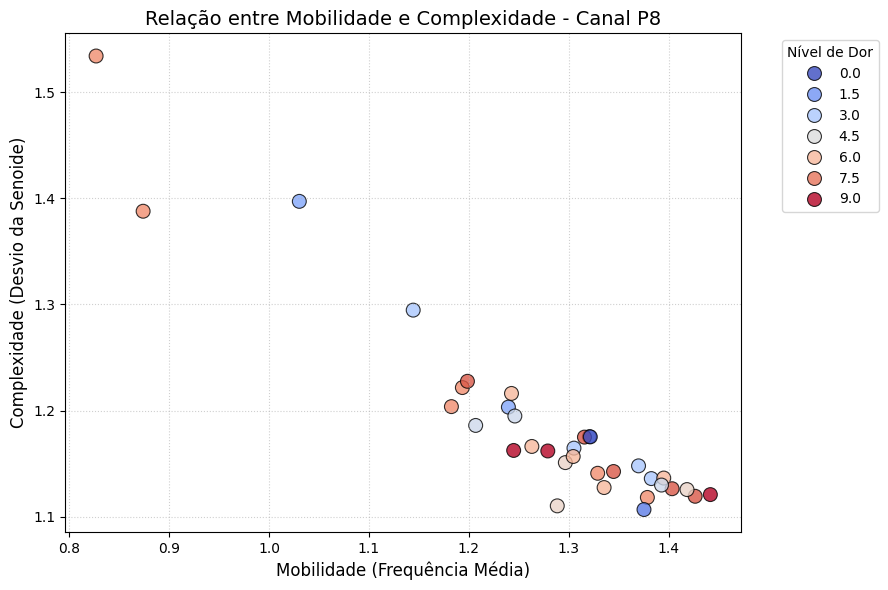

In [ ]:
canal_alvo = 'P8' # pode escolher qualquer canal
col_mobility = f'Hjorth_Mobility_{canal_alvo}'
col_complexity = f'Hjorth_Complexity_{canal_alvo}'

if col_mobility in df_hjorth.columns and col_complexity in df_hjorth.columns:
    plt.figure(figsize=(9, 6))
    
    scatter = sns.scatterplot(data=df_hjorth, x=col_mobility, y=col_complexity, 
                              hue='Pain_Score', palette='coolwarm', s=100, edgecolor='black', alpha=0.8)
    
    plt.title(f'Relação entre Mobilidade e Complexidade - Canal {canal_alvo}', fontsize=14)
    plt.xlabel('Mobilidade (Frequência Média)', fontsize=12)
    plt.ylabel('Complexidade (Desvio da Senoide)', fontsize=12)
    plt.legend(title='Nível de Dor', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('comAssimetria_mobility_complexity_hjorth_apen.png', dpi=300, bbox_inches='tight')
    plt.show()

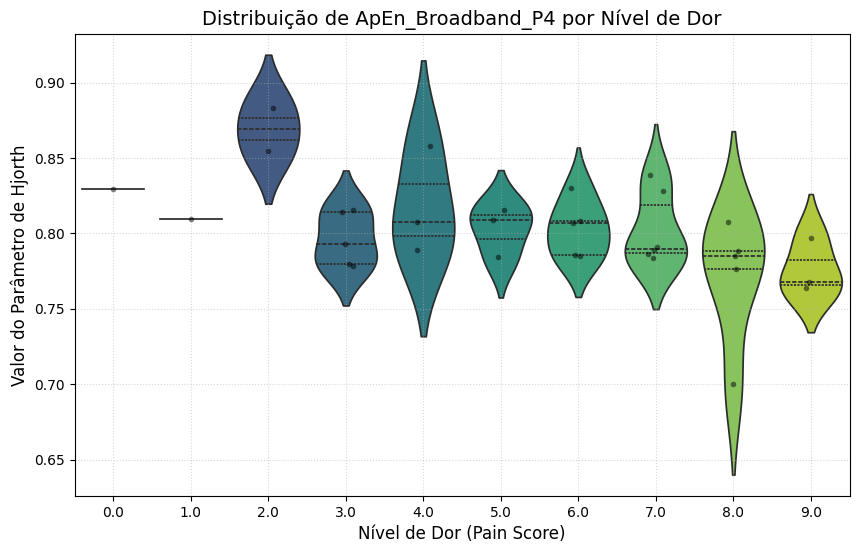

In [ ]:
melhor_feature = top_hjorth_features[0] # pode pegar qualquer feature do array tbm

plt.figure(figsize=(10, 6))
sns.violinplot(x='Pain_Score', y=melhor_feature, data=df_hjorth, palette='viridis', inner="quartile")
sns.stripplot(x='Pain_Score', y=melhor_feature, data=df_hjorth, color='black', alpha=0.5, size=4)

plt.title(f'Distribuição de {melhor_feature} por Nível de Dor', fontsize=14)
plt.xlabel('Nível de Dor (Pain Score)', fontsize=12)
plt.ylabel('Valor do Parâmetro de Hjorth', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.savefig('comAssimetria_P4_hjorth_apen.png', dpi=300, bbox_inches='tight')
plt.show()